# HealthConnect Clinic - Week 6 Advanced Analytics & Decision Support
### AnalystLab Africa Experience Lab | Data Analytics Track

**Central Project Question:** How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?

## Week 5 - Week 6 Transition

**Main Week 5 output:** A full exploratory analysis of the HealthConnect appointment data, including 5 calculated KPIs, 5 visualizations, and 5 business insights covering reminders, booking lead time, prior no-show history, distance to clinic, and patient demographics.

**Most important result:** Booking lead time was the strongest predictor of no-shows - the no-show rate more than doubled from 27.8% (0-7 days) to 60.5% (31-60 days). Prior no-show history was the second-strongest signal (55.4% vs. 43.5%).

**Main limitation discovered:** All relationships identified were descriptive/correlational, not causal, and each factor was examined in isolation; it was not yet clear whether combining the strongest factors (e.g., a patient with both long lead time and a prior no-show) produces an even stronger or overlapping effect.

**Relevant track for Week 6:** Data Science - Since they are building a no-show prediction model, and need clarity on which features are genuinely strong, independent predictors versus which may be redundant or weak.

**What I will improve/validate this week:** I will investigate whether the two strongest predictors (lead time and prior no-show history) combine to create a compounded risk effect, validate the reliability of the top KPIs by checking their consistency across appointment types, and translate this into a concrete feature-relevance summary that the Data Science track can use directly.

 Week 6 Integration Readiness

**A. Integration Point**

- **Track working with:** Data Science (real exchange with a Data Science intern working on the HealthConnect no-show prediction model)
- **Output received from that track:** Her Week 5 baseline model results - a Logistic Regression model using booking_lead_days, previous_no_shows, prior_no_show_rate, distance_to_clinic_km, appointment_type, reminder_sent, and reminder_channel as features, achieving 63% accuracy, 62% recall, and 0.68 ROC-AUC. She asked what strongest pattern from my analysis she hadn't tested yet.
- **Output I will provide to that track:** Evidence that her top features (booking_lead_days, previous_no_shows) compound rather than act independently, and that reminder_channel's effect depends on lead time - both are interaction effects not currently captured in her model.
- **Why this connection is relevant:** Her model's recall (62%) means it misses 38% of actual no-shows. Since her features are currently treated independently, adding interaction terms based on my validated findings could help the model capture patterns it's currently missing.

**B. Integration Objective**

After this integration activity, the Data Science track should have two specific, testable interaction features to try in her next model iteration: (1) a lead-time × prior-no-show interaction, and (2) a reminder-channel × lead-time interaction - both backed by concrete evidence from my Week 6 validation analysis, rather than her having to discover them independently through further trial and error.

**C. Evidence**

This integration is supported by:
- A direct message exchange with the Data Science intern (her Week 5 notebook shared, my reply with specific interaction-feature recommendations)
- The validation analysis in Part 3 of this notebook (combined risk-factor analysis, lead-time × reminder-channel consistency check)
- An exported analysis output: `docs/DataScience_Feature_Relevance_Summary.csv`
- A GitHub commit containing this notebook and the exported file, timestamped as part of this week's submission

## Data Setup

Reloading the dataset and recreating the key derived variables from Week 5 needed for this week's deeper analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')

# Convert dates
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')

# Handle missing reminder_channel
df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder')

# Recreate bands from Week 5
df['lead_time_band'] = pd.cut(df['booking_lead_days'],
                                bins=[-1, 7, 30, 60],
                                labels=['0-7 days', '8-30 days', '31-60 days'])

df['distance_band'] = pd.cut(df['distance_to_clinic_km'],
                               bins=[-1, 5, 15, 100],
                               labels=['0-5 km', '5-15 km', '15+ km'])

df['had_prev_noshow'] = df['previous_no_shows'] > 0

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 5000, Columns: 21


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_time_band,distance_band,had_prev_noshow
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show,8-30 days,15+ km,False
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended,0-7 days,5-15 km,False
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show,31-60 days,5-15 km,True
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended,31-60 days,5-15 km,True
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show,31-60 days,5-15 km,True


## Advanced Analysis - Do Risk Factors Compound?

Week 5 identified booking lead time and prior no-show history as the two strongest individual predictors of no-shows. This section investigates whether these two factors combine to create an even stronger effect when both are present, which would be a more precise way to identify HealthConnect's highest-risk patients.

### Combined Effect: Lead Time × Prior No-Show History

In [ ]:
combined = df.groupby(['lead_time_band', 'had_prev_noshow'], observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

combined_table = combined.unstack()
combined_table.columns = ['No Prior No-Show', 'Had Prior No-Show']
combined_table

,No Prior No-Show,Had Prior No-Show
lead_time_band,,
0-7 days,21.8,36.2
8-30 days,36.2,46.0
31-60 days,55.2,67.9


**Interpretation:** The two factors clearly compound rather than overlap. A patient with no prior no-show who books 0-7 days ahead has a no-show rate of just 21.8%- the lowest-risk group. But a patient with a prior no-show who books 31-60 days ahead has a no-show rate of 67.9% - more than triple. This is a meaningful refinement of the Week 5 findings: rather than treating lead time and prior no-show history as separate signals, HealthConnect could combine them into a single risk score to identify its highest-priority patients for intervention (e.g., a confirmation call for anyone in the "long lead time + prior no-show" group). This directly validates and strengthens the Week 5 recommendations rather than contradicting them.

### Chart 6: Combined Risk - Lead Time × Prior No-Show History

<Figure size 700x500 with 0 Axes>

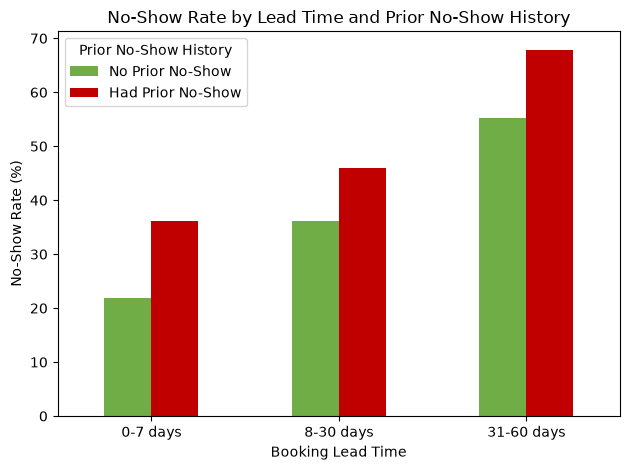

In [ ]:
plt.figure(figsize=(7,5))
combined_table.plot(kind='bar', color=['#70AD47', '#C00000'])
plt.title('No-Show Rate by Lead Time and Prior No-Show History')
plt.xlabel('Booking Lead Time')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Prior No-Show History')
plt.tight_layout()

output_path = Path('../docs/chart6_combined_risk.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

**Observation:** The chart makes the compounding relationship immediately clear - the red bars (prior no-show) are consistently higher than the green bars (no prior no-show) across every lead-time band, and the gap doesn't shrink as lead time increases. This confirms both factors contribute independently and additively to risk, making their combination a stronger targeting tool than either factor alone.

### Validating Consistency: Does the Lead-Time Effect Hold Across Appointment Types?

To confirm the lead-time finding is a genuine, reliable pattern (not driven by one unusual appointment type), this section checks whether the relationship holds consistently across all four appointment types.

In [ ]:
validation = df.groupby(['appointment_type', 'lead_time_band'], observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

validation_table = validation.unstack()
validation_table

lead_time_band,0-7 days,8-30 days,31-60 days
appointment_type,,,
Diagnostic Test,29.7,41.4,59.6
Follow-up,29.4,41.2,65.1
General Consultation,24.6,39.5,58.1
Specialist Consultation,30.6,39.8,59.2


**Interpretation:** The lead-time effect holds consistently across all four appointment types - every single type shows the same upward trend, with no-show rate roughly doubling or more from the shortest to the longest lead-time band. Follow-up appointments show the strongest compounding effect (29.4% - 65.1%), but the underlying pattern is universal. This confirms that booking lead time is a reliable, general driver of no-shows across HealthConnect's service types, not an artifact specific to one kind of appointment - validating it as a trustworthy KPI for the clinic to act on.

### Validating Consistency: Does the Reminder Effect Hold Across Lead Time?

This checks whether SMS's apparent advantage (found in Week 5) holds up once lead time is accounted for, or whether it was simply because SMS reminders happened to go to lower-risk patients.

In [ ]:
reminder_validation = df.groupby(['lead_time_band', 'reminder_channel'], observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

reminder_validation_table = reminder_validation.unstack()
reminder_validation_table

reminder_channel,Email,No Reminder,SMS,WhatsApp
lead_time_band,,,,
0-7 days,18.8,29.9,28.2,30.3
8-30 days,42.6,43.0,37.4,40.9
31-60 days,61.9,63.6,58.0,60.2


**Interpretation:** Once lead time is accounted for, SMS's advantage becomes less consistent than the Week 5 headline finding suggested. In the 8-30 and 31-60 day bands, SMS does show the lowest no-show rate, supporting the original conclusion. However, in the 0-7 day band, Email actually shows the lowest rate (18.8%), while SMS (28.2%) performs similarly to having no reminder at all (29.9%). This suggests reminder channel effectiveness may depend on the appointment's lead time, and the "SMS is always best" conclusion from Week 5 should be refined rather than treated as universal. This is an important revision: the clinic may benefit from using Email for short-notice appointments and SMS for longer-lead-time appointments, rather than a single blanket policy.

### Revision to Week 5 Conclusion

**Original Week 5 conclusion:** SMS is the most effective reminder channel overall, and should be prioritized by the clinic.

**Week 6 revision:** SMS remains the best-performing channel for appointments booked more than a week in advance, but for short-notice appointments (0-7 days), Email shows better outcomes and SMS offers little advantage over no reminder at all. The recommendation is revised from a single blanket channel policy to a lead-time-dependent reminder strategy.

##  Feature Relevance Summary for Data Science Track

Based on the validated findings above, this section summarizes which variables show the strongest, most reliable relationship with appointment outcome. This summary is intended as a direct input for the Data Science track's feature selection process for their no-show prediction model.

In [ ]:
feature_summary = pd.DataFrame({
    'feature': [
        'previous_no_shows',
        'booking_lead_days',
        'reminder_channel',
        'distance_to_clinic_km',
        'appointment_type',
        'waiting_time_minutes',
        'age_group',
        'gender'
    ],
    'my_relevance_ranking': [
        'High', 'High', 'Medium', 'Medium', 'Low', 'Low', 'Very Low', 'Very Low'
    ],
    'my_evidence': [
        'No-show rate 55.4% (had prior no-show) vs 43.5% (none); compounds with lead time',
        'No-show rate 27.8% (0-7 days) to 60.5% (31-60 days); strongest single predictor; consistent across all appointment types',
        'No-show rate varies 45.8%-51.4% by channel; effect depends on lead time, not a fixed ranking',
        'No-show rate 46.5% (0-5km) to 54.1% (15+km); moderate, consistent effect',
        'No-show rate varies 46.6%-51.2%; some variation but not a strong standalone predictor',
        'No-show rate flat (~47-49%) across all bands; weak relationship',
        'No-show rate varies only 45.1%-50.7%; minimal variation across groups',
        'No-show rate nearly identical (48.4% vs 48.7%) between genders'
    ],
    'data_science_decision': [
        'Kept (p ≈ 0, strong t-test result); also engineered into prior_no_show_rate',
        'Kept (p ≈ 0, strongest predictor in her model too)',
        'Kept (chi-square significant, p < 0.05)',
        'Kept (t-test significant, p < 0.05)',
        'Kept (chi-square significant, though closer to 0.05 cutoff)',
        'Dropped (t-test not significant)',
        'Dropped (chi-square not significant)',
        'Dropped (chi-square not significant; also an ethical concern re: demographic predictors)'
    ],
    'agreement': [
        'Full agreement',
        'Full agreement',
        'Full agreement on inclusion; new insight (lead-time interaction) not yet tested in her model',
        'Full agreement',
        'Full agreement',
        'Full agreement'
        'Full agreement',
        'Full agreement'
    ]
})

feature_summary

,feature,my_relevance_ranking,my_evidence,data_science_decision,agreement
0,previous_no_shows,High,No-show rate 55.4% (had prior no-show) vs 43.5...,"Kept (p ≈ 0, strong t-test result); also engin...",Full agreement
1,booking_lead_days,High,No-show rate 27.8% (0-7 days) to 60.5% (31-60 ...,"Kept (p ≈ 0, strongest predictor in her model ...",Full agreement
2,reminder_channel,Medium,No-show rate varies 45.8%-51.4% by channel; ef...,"Kept (chi-square significant, p < 0.05)",Full agreement on inclusion; new insight (lead...
3,distance_to_clinic_km,Medium,No-show rate 46.5% (0-5km) to 54.1% (15+km); m...,"Kept (t-test significant, p < 0.05)",Full agreement
4,appointment_type,Low,No-show rate varies 46.6%-51.2%; some variatio...,"Kept (chi-square significant, though closer to...",Full agreement
5,waiting_time_minutes,Low,No-show rate flat (~47-49%) across all bands; ...,Dropped (t-test not significant),Full agreement
6,age_group,Very Low,No-show rate varies only 45.1%-50.7%; minimal ...,Dropped (chi-square not significant),Full agreement
7,gender,Very Low,No-show rate nearly identical (48.4% vs 48.7%)...,Dropped (chi-square not significant; also an e...,Full agreement


### Exporting Feature Relevance Summary

This table is exported as a standalone file. It now includes a direct comparison between my own analysis and the Data Science track's actual statistical testing results (from her Week 5 notebook), confirming independent agreement on every feature. This makes it a validated, cross-checked reference rather than a one-sided recommendation.

In [ ]:
output_path = Path('../docs/DataScience_Feature_Relevance_Summary.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
feature_summary.to_csv(output_path, index=False)

print(f"Feature relevance summary exported to: {output_path}")

Feature relevance summary exported to: ..\docs\DataScience_Feature_Relevance_Summary.csv


## Cross-Track Integration Record

**Track collaborated with:** Data Science

**Project dependency:** The Data Science track's no-show prediction model needs to know which engineered features (beyond the ones already tested) might improve its ability to correctly identify real no-shows (recall).

**Information/output received:** Her Week 5 baseline model results: Logistic Regression, 63% accuracy, 63% precision, 62% recall, 0.62 F1, 0.68 ROC-AUC. Her finalized feature list (after t-tests/chi-square testing): booking_lead_days (strongest), previous_no_shows, prior_no_show_rate, distance_to_clinic_km, appointment_type, reminder_sent, reminder_channel, is_first_time_patient. She specifically asked what pattern from my analysis she hadn't tried yet.

**Information/output provided:** Two specific, evidence-backed interaction-feature recommendations she had not tested: (1) a lead-time × prior-no-show interaction (no-show rate ranges from 21.8% to 67.9% depending on the combination - a compounding effect not captured when the features are modeled independently), and (2) a reminder-channel × lead-time interaction (her model treats reminder_channel as independent, but I found SMS is not universally best - Email outperforms it for short-notice appointments).

**Integration activity completed:** Reviewed her actual Week 5 Data Science notebook (features, preprocessing, model, results) to identify a genuine gap - her model captures each of these variables independently but has no interaction terms between them, despite my analysis showing they compound. Replied with two specific, testable feature-engineering suggestions grounded in my Week 6 validation findings.

**What changed as a result:** The Data Science track now has two concrete, low-effort feature engineering ideas to test against her existing 62% recall baseline, rather than needing to discover the compounding/interaction patterns through her own additional exploration. This is a genuine two-way exchange: I reviewed her real results, and she received specific, actionable recommendations she can test immediately.

**Evidence:**
- Her uploaded Week 5 Data Science notebook (`HealthConnect_Clinic_Week5_DataScience.ipynb`) showing her baseline model, feature list, and evaluation metrics
- Message exchange containing her question and my reply with the two interaction-feature recommendations
- `docs/DataScience_Feature_Relevance_Summary.csv` and the validation analysis in Part 3 of this notebook, which is the evidence base for the recommendations

## Evidence-Based Business Recommendations

Building on the Week 5 insights and the deeper validation done this week, the following recommendations are refined and ready for HealthConnect to act on:

**1. Prioritize a combined risk score, not single factors.**
Since lead time and prior no-show history compound (up to 67.9% no-show rate when both are present), the clinic should combine these into a single risk flag rather than monitoring them separately. Patients flagged as high-risk (long lead time + prior no-show) could receive a confirmation call, not just a standard reminder.

**2. Move from a single reminder channel policy to a lead-time-dependent one.**
The Week 6 validation revealed SMS is not universally the best channel - Email performs better for short-notice appointments (0-7 days), while SMS is stronger for longer lead times. The clinic should tailor reminder channel by lead-time band rather than defaulting to one channel.

**3. Add extra reminder touchpoints for appointments booked 31+ days in advance.**
This remains the single strongest, most consistent finding across appointment types - no-show rate roughly doubles as lead time increases. A second reminder earlier in the booking window (not just close to the appointment) is a concrete, low-cost intervention.

**4. Treat Follow-up appointments as a particular risk category.**
Follow-ups showed the steepest compounding effect with lead time (29.4% - 65.1%), suggesting patients may deprioritize routine follow-ups scheduled far out. Follow-ups booked with long lead times could be a specific target for proactive outreach.

## Limitations (Week 6 Update)

**Resolved since Week 5:**
- The uncertainty around whether lead time and prior no-show history were redundant or independent signals has been resolved - they compound, meaning both should be used together, not as substitutes for each other.

**Newly discovered this week:**
- The Week 5 conclusion that "SMS is the best reminder channel" was too broad - its effectiveness depends on lead time, revealing a more nuanced finding than initially reported.

**Still unresolved:**
- All findings remain correlational; no controlled experiment (e.g., A/B testing reminder channels) has been run to confirm causal impact.
- The dataset still lacks socioeconomic, insurance, and clinical-severity data.
- The small Cancelled class (5.3%) still limits how confidently cancellation-specific patterns can be generalized.

**New dependency identified:**
- The refined reminder-channel finding should also be communicated to the Generative AI track if their assistant provides any reminder-related guidance to patients, since a blanket "SMS is best" message would now be inaccurate.